# Flower Classification with MobileNetV2

## A complete transfer-learning CNN for local Jupyter Notebook

This notebook builds a model for the  TensorFlow flower dataset:

- Daisy
- Dandelion
- Roses
- Sunflowers
- Tulips





## 0. Install packages only if required

The installation command is commented so it does not run accidentally. If a library is missing, remove the first hash symbol, run the cell once and restart the Jupyter kernel.

In Jupyter, %pip installs packages into the environment used by the current notebook kernel.

In [1]:
# Run only if the packages are missing:
%pip install tensorflow scikit-learn matplotlib seaborn pillow

Note: you may need to restart the kernel to use updated packages.


## 1. Import libraries

- pathlib handles Windows, Linux and macOS paths safely.
- random and NumPy help with reproducibility and numerical work.
- Matplotlib and Seaborn create plots.
- TensorFlow/Keras build and train the CNN.
- scikit-learn creates stratified splits and evaluation reports.

In [2]:
import pathlib
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report 
from sklearn.metrics import confusion_matrix

## 2. Configuration and reproducibility

Keeping configuration values in one cell makes the experiment easier to modify.

In [3]:
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 5
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

TensorFlow version: 2.21.0
Image size: (224, 224)
Batch size: 32


### Arguments explained

- SEED fixes random operations so repeated runs are more comparable. Any fixed integer can be used.
- IMAGE_SIZE sets height and width to 224 pixels, the input size used for this MobileNetV2 model.
- BATCH_SIZE = 32 means the model processes 32 images before one weight update.
- INITIAL_EPOCHS is the maximum number of feature-extraction training passes.
- FINE_TUNE_EPOCHS is the maximum number of optional fine-tuning passes.
- The three seed functions control Python, NumPy and TensorFlow randomness.



## 3. Download the flower dataset

Keras downloads and extracts the dataset automatically. On later runs, it normally reuses the cached copy.

In [4]:
DATASET_URL = (
    "https://storage.googleapis.com/"
    "download.tensorflow.org/example_images/flower_photos.tgz"
)

downloaded_path = keras.utils.get_file(
    fname="flower_photos",#dataset name
    origin=DATASET_URL,#download address
    untar=True #extracts compressed archive data
)

data_dir = pathlib.Path(downloaded_path)

print("Dataset folder:", data_dir)
print("Folder exists:", data_dir.exists())

Dataset folder: C:\Users\Admin\.keras\datasets\flower_photos
Folder exists: True


### Arguments explained

- fname gives the cached dataset a name.
- origin is the download address.
- untar=True extracts the compressed archive.
- pathlib.Path converts the returned string into a portable path.
- exists() checks that the folder is available.



In [5]:
data_dir = pathlib.Path(downloaded_path)
nested_folder = data_dir / "flower_photos"
if nested_folder.is_dir():
    data_dir = nested_folder
print("Correct dataset folder:", data_dir)
print("Folders inside:", [
    folder.name
    for folder in data_dir.iterdir()
    if folder.is_dir()
])

Correct dataset folder: C:\Users\Admin\.keras\datasets\flower_photos\flower_photos
Folders inside: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## 4. Discover classes and collect file paths

Only file locations and small integer labels are stored. Image pixels are not loaded yet, which keeps memory usage low.

In [6]:
class_names = sorted([
    folder.name
    for folder in data_dir.iterdir()
    if folder.is_dir()
])
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}
NUM_CLASSES = len(class_names)
file_paths = []
labels = []
for class_name in class_names:
    class_folder = data_dir / class_name
    class_index = class_to_index[class_name]

    for image_path in sorted(class_folder.glob("*.jpg")):
        file_paths.append(str(image_path))
        labels.append(class_index)
file_paths = np.array(file_paths)
labels = np.array(labels)
print("Classes:", class_names)
print("Mapping:", class_to_index)
print("Number of classes:", NUM_CLASSES)
print("Number of images:", len(file_paths))
print("Labels shape:", labels.shape)
print("Example path:", file_paths[0])

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Mapping: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}
Number of classes: 5
Number of images: 3670
Labels shape: (3670,)
Example path: C:\Users\Admin\.keras\datasets\flower_photos\flower_photos\daisy\100080576_f52e8ee070_n.jpg


### Detailed explanation

- iterdir() visits items in the dataset directory.
- is_dir() keeps class folders and ignores ordinary files.
- sorted() produces a consistent alphabetical order.
- enumerate() pairs each class name with 0, 1, 2 and so on.
- data_dir / class_name safely creates a folder path.
- glob("*.jpg") selects JPEG images only.
- str(image_path) converts a Path object into a TensorFlow-friendly string.
- np.array converts Python lists into arrays for splitting.



## 5. Inspect class distribution

This check shows whether one class has substantially more images than another.

daisy       : 633 images
dandelion   : 898 images
roses       : 641 images
sunflowers  : 699 images
tulips      : 799 images


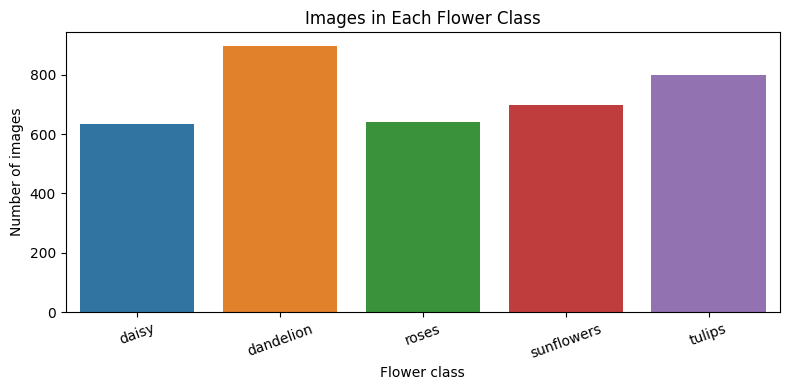

In [7]:
class_counts = np.bincount(labels, minlength=NUM_CLASSES)
for class_name, count in zip(class_names, class_counts):
    print(f"{class_name:12s}: {count} images")
plt.figure(figsize=(8, 4))
sns.barplot(
    x=class_names,
    y=class_counts,
    hue=class_names,
    legend=False
)
plt.title("Images in Each Flower Class")
plt.xlabel("Flower class")
plt.ylabel("Number of images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Inference

- np.bincount counts occurrences of every integer class label.
- minlength guarantees a count for every class.
- The dataset is not perfectly balanced, but every class has many examples.
  

## 6. Create training, validation and test sets

The split is:

- 70% training: updates weights.
- 15% validation: controls training decisions.
- 15% test: provides final evaluation.

In [9]:
train_paths, temporary_paths, train_labels, temporary_labels = train_test_split(
    file_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)
validation_paths, test_paths, validation_labels, test_labels = train_test_split(temporary_paths,
    temporary_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_labels
)

print("Training images:", len(train_paths))
print("Validation images:", len(validation_paths))
print("Test images:", len(test_paths))
print(
    "Total:",
    len(train_paths) + len(validation_paths) + len(test_paths)
)

Training images: 2569
Validation images: 550
Test images: 551
Total: 3670


### Arguments explained

First split:

- test_size=0.30 reserves 30% temporarily and leaves 70% for training.
- random_state=SEED makes the split reproducible.
- stratify=labels preserves flower proportions.

Second split:

- test_size=0.50 divides the temporary 30% equally, giving approximately 15% validation and 15% test data.
- stratify=temporary_labels preserves class proportions again.

### Inference

All three printed counts should add up to the total number of images. The test images are excluded from model-selection decisions.

## 7. Verify the class proportions

In [10]:
def print_split_distribution(split_name, split_labels):
    counts = np.bincount(
        split_labels,
        minlength=NUM_CLASSES
    )
    percentages = counts / len(split_labels) * 100

    print(f"\n{split_name}")
    for class_name, count, percentage in zip(
        class_names,
        counts,
        percentages
    ):
        print(
            f"{class_name:12s}: "
            f"{count:4d} ({percentage:5.1f}%)"
        )


print_split_distribution("Training set", train_labels)
print_split_distribution("Validation set", validation_labels)
print_split_distribution("Test set", test_labels)


Training set
daisy       :  443 ( 17.2%)
dandelion   :  629 ( 24.5%)
roses       :  449 ( 17.5%)
sunflowers  :  489 ( 19.0%)
tulips      :  559 ( 21.8%)

Validation set
daisy       :   95 ( 17.3%)
dandelion   :  134 ( 24.4%)
roses       :   96 ( 17.5%)
sunflowers  :  105 ( 19.1%)
tulips      :  120 ( 21.8%)

Test set
daisy       :   95 ( 17.2%)
dandelion   :  135 ( 24.5%)
roses       :   96 ( 17.4%)
sunflowers  :  105 ( 19.1%)
tulips      :  120 ( 21.8%)


### Inference

Similar percentages for a given flower across the three sections confirm that stratification worked. The function prevents us from repeating the same calculation three times.

## 8. Build a memory-efficient tf.data pipeline

Images are read and resized only when their batches are needed.

In [12]:
AUTOTUNE = tf.data.AUTOTUNE
def load_and_resize_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)

    image = tf.io.decode_jpeg(
        image_bytes,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


def make_dataset(paths, target_labels,training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, target_labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_resize_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = make_dataset(
    train_paths,
    train_labels,
    training=True
)

validation_ds = make_dataset(
    validation_paths,
    validation_labels
)

test_ds = make_dataset(
    test_paths,
    test_labels
)

## 9. Inspect one batch before training

In [13]:
image_batch, label_batch = next(iter(train_ds))

print("Image batch shape:", image_batch.shape)
print("Label batch shape:", label_batch.shape)
print(
    "Minimum pixel value:",
    tf.reduce_min(image_batch).numpy()
)
print(
    "Maximum pixel value:",
    tf.reduce_max(image_batch).numpy()
)
print("First five labels:", label_batch[:5].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 255.0
First five labels: [0 4 3 4 4]


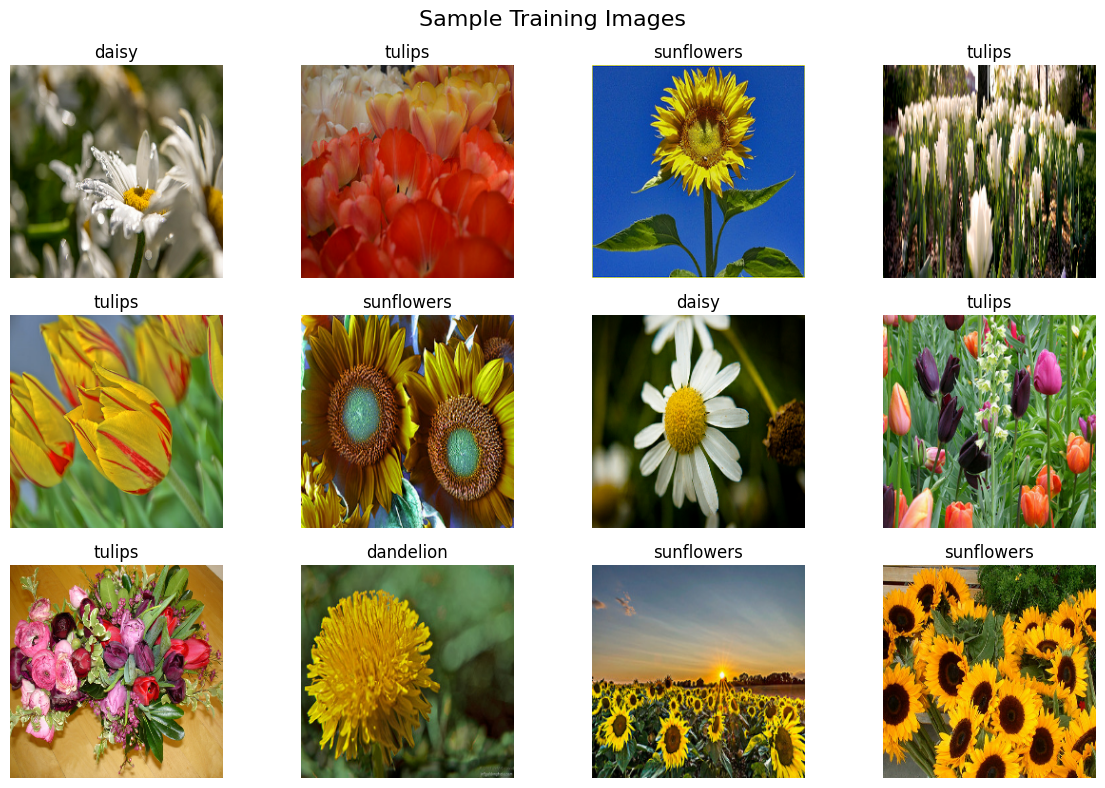

In [14]:
plt.figure(figsize=(12, 8))

for index in range(12):
    plt.subplot(3, 4, index + 1)

    plt.imshow(
        tf.cast(
            image_batch[index],
            tf.uint8
        )
    )

    label_number = label_batch[index].numpy()
    plt.title(class_names[label_number])
    plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.show()

## 11. Data augmentation

Augmentation produces realistic variations of training images so the model learns general patterns rather than exact photographs. These layers are active only during training.

In [15]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

## 12. Visualize augmentation

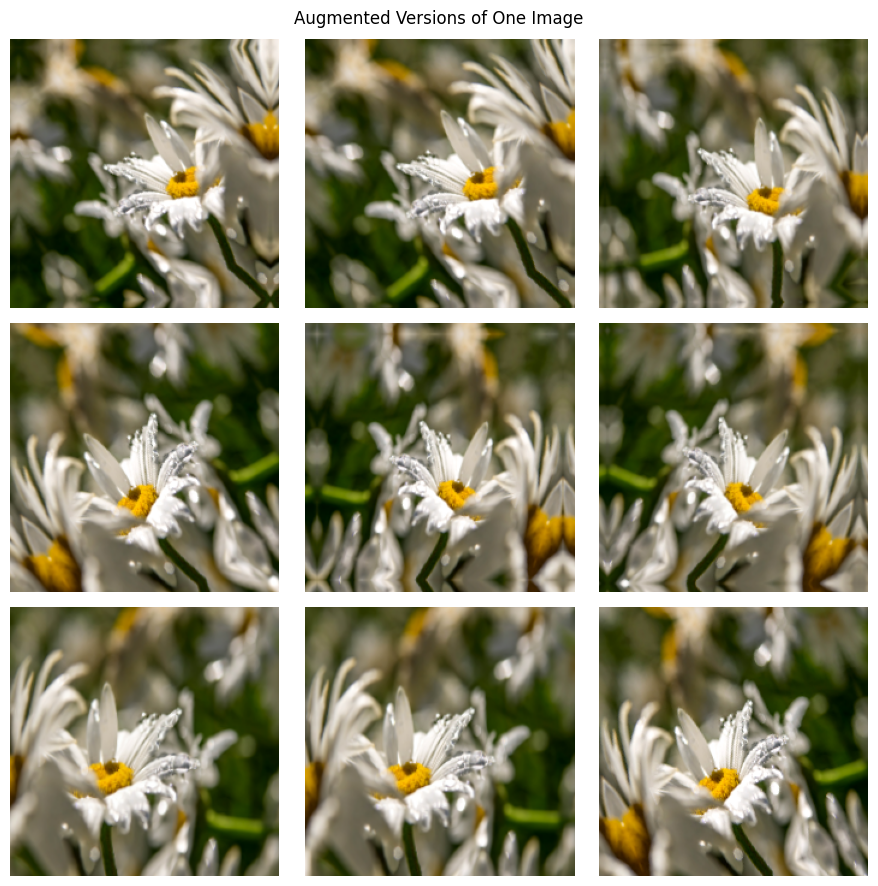

In [16]:
sample_image = image_batch[0]

plt.figure(figsize=(9, 9))

for index in range(9):
    augmented_batch = data_augmentation(
        tf.expand_dims(
            sample_image,
            axis=0
        ),
        training=True
    )

    plt.subplot(3, 3, index + 1)
    plt.imshow(
        tf.cast(
            augmented_batch[0],
            tf.uint8
        )
    )
    plt.axis("off")

plt.suptitle("Augmented Versions of One Image")
plt.tight_layout()
plt.show()

### Explanation and inference

- expand_dims(axis=0) changes one image from (224, 224, 3) to a one-image batch (1, 224, 224, 3).
- training=True deliberately turns augmentation on for the demonstration.
- augmented_batch[0] removes the one-image batch dimension for display.
- The nine results should look different but must remain recognizable as the same flower.

## 13. Load pretrained MobileNetV2

MobileNetV2 has already learned useful visual features from ImageNet.

In [17]:
base_model = keras.applications.MobileNetV2(
    input_shape=IMAGE_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNet input shape:", base_model.input_shape)
print("MobileNet output shape:", base_model.output_shape)
print("MobileNet layers:", len(base_model.layers))

MobileNet input shape: (None, 224, 224, 3)
MobileNet output shape: (None, 7, 7, 1280)
MobileNet layers: 154


In [18]:
inputs = keras.Input(
    shape=IMAGE_SIZE + (3,),
    name="input_image"
)

x = data_augmentation(inputs)

x = keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    rate=0.25,
    name="dropout"
)(x)

outputs = layers.Dense(
    units=NUM_CLASSES,
    activation="softmax",
    name="flower_predictions"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_Flower_Classifier"
)

## 15. Inspect trainable parameters

In [19]:
model.summary()

trainable_parameters = np.sum([
    np.prod(variable.shape)
    for variable in model.trainable_weights
])

non_trainable_parameters = np.sum([
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
])

print("Trainable parameters:", trainable_parameters)
print("Non-trainable parameters:", non_trainable_parameters)

Model: "MobileNetV2_Flower_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flower_predictions (Dense)      │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Trainable parameters: 6405
Non-trainable parameters: 2257984


## 16. Compile the model

In [20]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

## 17. Define training callbacks

In [21]:
checkpoint_path = "best_mobilenetv2_flowers.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [22]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

Epoch 1/10


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.6353 - loss: 0.9366
Epoch 1: val_accuracy improved from None to 0.77818, saving model to best_mobilenetv2_flowers.keras

Epoch 1: finished saving model to best_mobilenetv2_flowers.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 69s 789ms/step - accuracy: 0.6353 - loss: 0.9366 - val_accuracy: 0.7782 - val_loss: 0.5786 - learning_rate: 0.0010
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.8132 - loss: 0.5106
Epoch 2: val_accuracy improved from 0.77818 to 0.85818, saving model to best_mobilenetv2_flowers.keras

Epoch 2: finished saving model to best_mobilenetv2_flowers.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 58s 718ms/step - accuracy: 0.8132 - loss: 0.5106 - val_accuracy: 0.8582 - val_loss: 0.4379 - learning_rate: 0.0010
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.8583 - loss: 0.3988
Epoch 3: val_accuracy improved from 0.85818 to 0.86909, saving model to best_mobilenetv2_flowers.keras

Epoch 3: finished saving model

## 19. Plot learning curves

In [ ]:
def plot_training_history(training_history, title_prefix="Phase 1"):
    completed_epochs = range(
        1,
        len(training_history.history["loss"]) + 1
    )

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(
        completed_epochs,
        training_history.history["accuracy"],
        marker="o",
        label="Training accuracy"
    )
    plt.plot(
        completed_epochs,
        training_history.history["val_accuracy"],
        marker="o",
        label="Validation accuracy"
    )
    plt.title(f"{title_prefix}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(
        completed_epochs,
        training_history.history["loss"],
        marker="o",
        label="Training loss"
    )
    plt.plot(
        completed_epochs,
        training_history.history["val_loss"],
        marker="o",
        label="Validation loss"
    )
    plt.title(f"{title_prefix}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_history(history)

## 20. Final evaluation on untouched test data

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

## 21. Detailed test predictions

In [ ]:
prediction_probabilities = model.predict(
    test_ds,
    verbose=1
)

predicted_labels = np.argmax(
    prediction_probabilities,
    axis=1
)

true_labels = np.concatenate([
    batch_labels.numpy()
    for _, batch_labels in test_ds
])

print(
    "Probability array shape:",
    prediction_probabilities.shape
)
print("Predicted labels shape:", predicted_labels.shape)
print("True labels shape:", true_labels.shape)
print(
    "First probability row:",
    prediction_probabilities[0]
)
print(
    "Probability sum:",
    prediction_probabilities[0].sum()
)

## 22. Classification report

In [ ]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=3,
        zero_division=0
    )
)

## 23. Confusion matrix

In [ ]:
matrix = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("MobileNetV2 Flower Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.show()

## 24. Visualize correct and incorrect predictions

In [ ]:
test_images, _ = next(iter(test_ds))
test_images = test_images.numpy()

plt.figure(figsize=(15, 12))

for index in range(12):
    confidence = prediction_probabilities[index].max()
    predicted_name = class_names[predicted_labels[index]]
    actual_name = class_names[true_labels[index]]

    title_color = (
        "green"
        if predicted_labels[index] == true_labels[index]
        else "red"
    )

    plt.subplot(3, 4, index + 1)
    plt.imshow(
        tf.cast(
            test_images[index],
            tf.uint8
        )
    )
    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Confidence: {confidence:.1%}",
        color=title_color,
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 25. Predict one new image

The preprocessing step is already inside the model, so the function should not manually divide pixels by 255.

In [ ]:
def predict_single_image(image_path, trained_model, names):
    image = keras.utils.load_img(
        image_path,
        target_size=IMAGE_SIZE
    )

    image_array = keras.utils.img_to_array(image)

    image_batch = tf.expand_dims(
        image_array,
        axis=0
    )

    probabilities = trained_model.predict(
        image_batch,
        verbose=0
    )[0]

    predicted_index = int(
        np.argmax(probabilities)
    )

    predicted_name = names[predicted_index]
    confidence = float(
        probabilities[predicted_index]
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"Prediction: {predicted_name}\n"
        f"Confidence: {confidence:.2%}"
    )
    plt.axis("off")
    plt.show()

    return predicted_name, confidence, probabilities

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

## 28. Fine-tune and re-evaluate

In [ ]:
fine_tune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_finetuned_mobilenetv2_flowers.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

fine_tune_history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

fine_tuned_test_loss, fine_tuned_test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(
    f"Fine-tuned test loss: "
    f"{fine_tuned_test_loss:.4f}"
)
print(
    f"Fine-tuned test accuracy: "
    f"{fine_tuned_test_accuracy:.2%}"
)

In [ ]:
FINAL_MODEL_PATH = (
    "mobilenetv2_flower_classifier.keras"
)

model.save(FINAL_MODEL_PATH)

print("Saved model:", FINAL_MODEL_PATH)